### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error

### Load Dataset

In [ ]:
df = pd.read_csv("../data/web_traffic_single_page.csv")

# Create Date column
df["Date"] = pd.date_range(start="2015-07-01", periods=len(df), freq="D")

# Set Date as index
df.set_index("Date", inplace=True)

df.head()


,Day,Visitors
Date,,
2015-07-01,1,11
2015-07-02,2,5
2015-07-03,3,13
2015-07-04,4,14
2015-07-05,5,9


In [72]:
df.to_csv("../data/Web_traffic_single_page_with_Date.csv")

### Rolling Mean (Trend Detection)

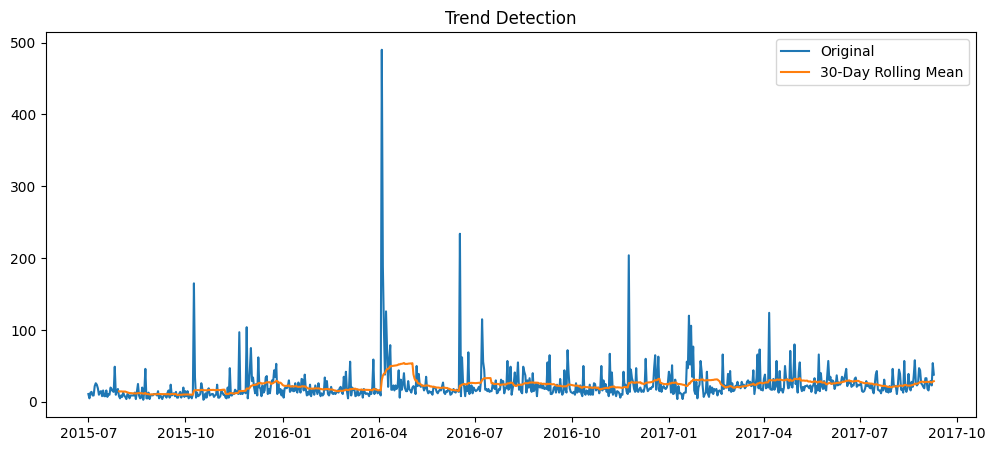

In [3]:
df["Rolling_Mean"] = df["Visitors"].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df["Visitors"], label="Original")
plt.plot(df["Rolling_Mean"], label="30-Day Rolling Mean")
plt.legend()
plt.title("Trend Detection")
plt.show()

### Time Series Decomposition

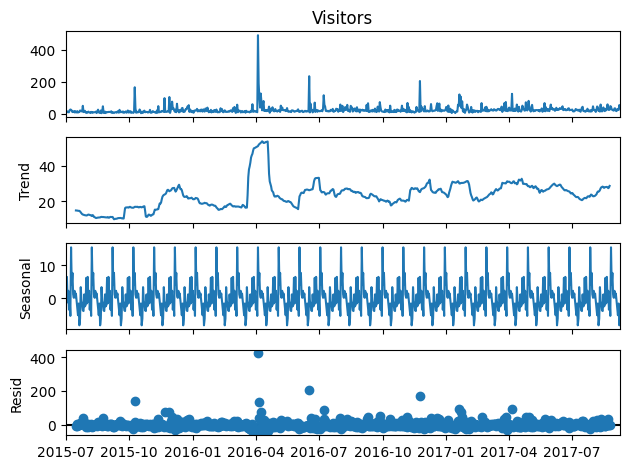

In [4]:
decomposition = seasonal_decompose(df["Visitors"], model="additive", period=30)

decomposition.plot()
plt.show()

### Stationarity Check (ADF Test)

In [ ]:
result = adfuller(df["Visitors"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

### If p-value < 0.05 → Data is stationary 

ADF Statistic: -10.684123742128996
p-value: 3.8723978712036864e-19


### Train-Test Split

In [7]:
train_size = int(len(df) * 0.8)

train = df["Visitors"][:train_size]
test = df["Visitors"][train_size:]

print("Train:", len(train))
print("Test:", len(test))

Train: 641
Test: 161


### ARIMA Model

In [8]:
arima_model = ARIMA(train, order=(2,0,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

c:\Users\HP\OneDrive\Desktop\website_traffic_forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Desktop\website_traffic_forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Desktop\website_traffic_forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### Evaluate ARIMA

In [9]:
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
mae_arima = mean_absolute_error(test, arima_forecast)

print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAE:", mae_arima)

ARIMA RMSE: 15.078377425827787
ARIMA MAE: 8.980165353296275


### Plot ARIMA

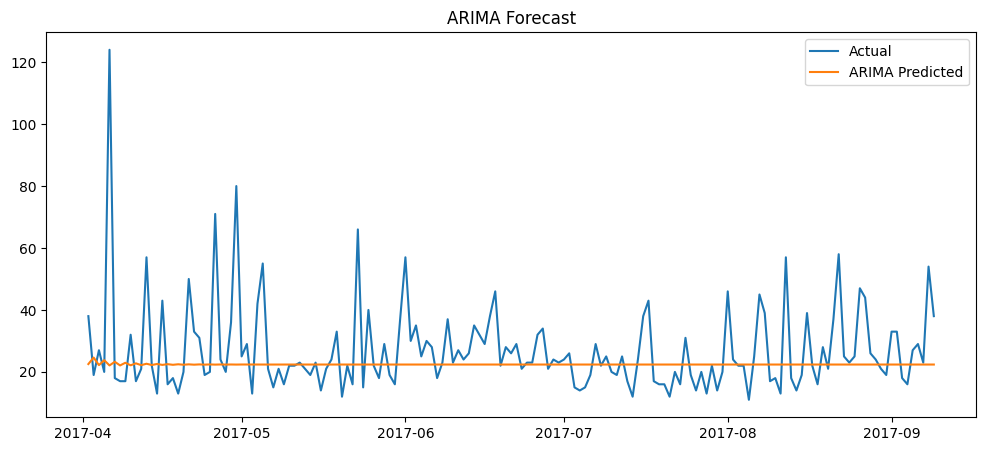

In [10]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA Predicted")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

### SARIMA Model

In [11]:
sarima_model = SARIMAX(train,
                       order=(2,0,2),
                       seasonal_order=(2,1,2,7))

sarima_fit = sarima_model.fit()
sarima_forecast = sarima_fit.forecast(steps=len(test))

c:\Users\HP\OneDrive\Desktop\website_traffic_forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Desktop\website_traffic_forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Desktop\website_traffic_forecasting\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))
mae_sarima = mean_absolute_error(test, sarima_forecast)

print("SARIMA RMSE:", rmse_sarima)
print("SARIMA MAE:", mae_sarima)

SARIMA RMSE: 15.223764319339917
SARIMA MAE: 9.177972472742411


### Plot SARIMA

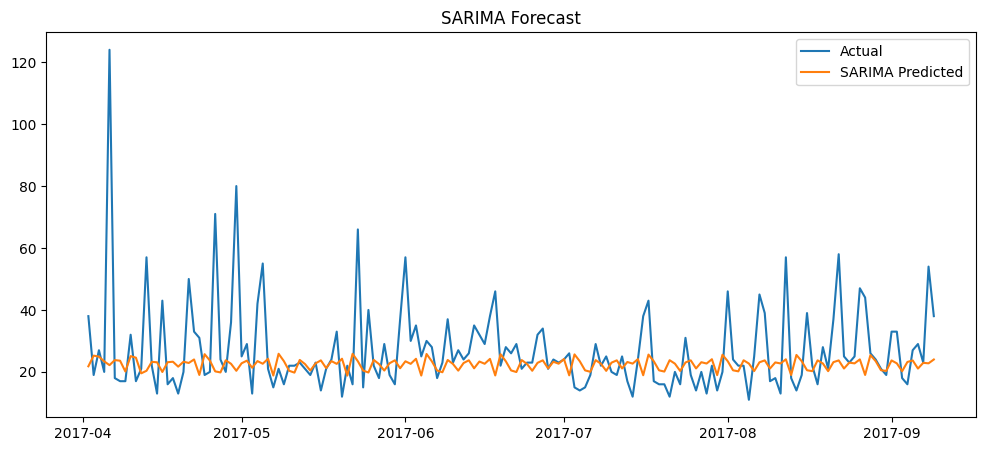

In [14]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Predicted")
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

### Compare Models

In [15]:
print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)

ARIMA RMSE: 15.078377425827787
SARIMA RMSE: 15.223764319339917


### Future Forecast (30 Days)

In [40]:
future_steps = 30

future_forecast = sarima_fit.forecast(steps=future_steps)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq='D'
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Visitors": future_forecast
})

future_df.set_index("Date", inplace=True)

print(future_df)

            Predicted_Visitors
Date                          
2017-09-10           21.806939
2017-09-11           25.255094
2017-09-12           24.926215
2017-09-13           23.400253
2017-09-14           22.179338
2017-09-15           23.818624
2017-09-16           23.610188
2017-09-17           20.133380
2017-09-18           25.096544
2017-09-19           24.590348
2017-09-20           19.535298
2017-09-21           20.360568
2017-09-22           23.248883
2017-09-23           23.103993
2017-09-24           19.973272
2017-09-25           23.127440
2017-09-26           23.283951
2017-09-27           21.697831
2017-09-28           23.283157
2017-09-29           22.882441
2017-09-30           24.019597
2017-10-01           19.015113
2017-10-02           25.719635
2017-10-03           23.661231
2017-10-04           20.166595
2017-10-05           19.834747
2017-10-06           23.753884
2017-10-07           22.613122
2017-10-08           20.361539
2017-10-09           22.784488


In [70]:
future_df.to_csv("../data/SARIMA_30_days_forecast.csv")

### Prepare Data for Facebook Prophet

In [41]:
prophet_df = df.reset_index()[["Date", "Visitors"]]
prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-07-01,11
1,2015-07-02,5
2,2015-07-03,13
3,2015-07-04,14
4,2015-07-05,9


### Train-Test Split

In [42]:
train_size = int(len(prophet_df) * 0.8)

train_prophet = prophet_df[:train_size]
test_prophet = prophet_df[train_size:]

### Train Prophet Model (For Evaluation)

In [65]:
from prophet import Prophet

model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model_prophet.fit(train_prophet)

00:18:40 - cmdstanpy - INFO - Chain [1] start processing
00:18:40 - cmdstanpy - INFO - Chain [1] done processing


### Predict on Test Data

In [44]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet))

forecast_prophet = model_prophet.predict(future)

### Extract Predictions for Test Set

In [46]:
forecast_test = forecast_prophet.iloc[-len(test_prophet):]["yhat"].values

In [47]:
rmse_prophet = np.sqrt(mean_squared_error(test_prophet["y"], forecast_test))
mae_prophet = mean_absolute_error(test_prophet["y"], forecast_test)

print("Prophet RMSE:", rmse_prophet)
print("Prophet MAE:", mae_prophet)

Prophet RMSE: 14.629833672726242
Prophet MAE: 9.285156152901349


### Plot Test Predictions

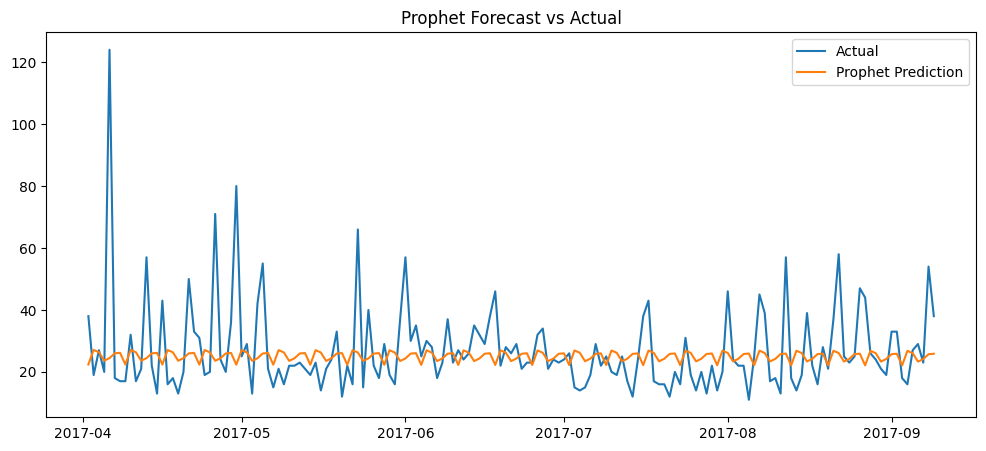

In [49]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet["ds"], test_prophet["y"], label="Actual")
plt.plot(test_prophet["ds"], forecast_test, label="Prophet Prediction")

plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.show()

### Train Final Model on Full Dataset

In [58]:
from prophet import Prophet

model_prophet_full = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model_prophet_full.fit(prophet_df)

00:16:10 - cmdstanpy - INFO - Chain [1] start processing
00:16:10 - cmdstanpy - INFO - Chain [1] done processing


### Forecast Next 30 Days

In [59]:
future_30 = model_prophet_full.make_future_dataframe(periods=30)

forecast_30 = model_prophet_full.predict(future_30)

### Extract only future Values

In [60]:
future_forecast = forecast_30.tail(30)[["ds", "yhat"]]

future_forecast.columns = ["Date", "Predicted_Visitors"]
future_forecast.set_index("Date", inplace=True)

print(future_forecast)

            Predicted_Visitors
Date                          
2017-09-10           19.454853
2017-09-11           21.860700
2017-09-12           21.300322
2017-09-13           18.145315
2017-09-14           19.894550
2017-09-15           20.012462
2017-09-16           20.051052
2017-09-17           17.368389
2017-09-18           20.360730
2017-09-19           20.428863
2017-09-20           17.927749
2017-09-21           20.338717
2017-09-22           21.108253
2017-09-23           21.770514
2017-09-24           19.666343
2017-09-25           23.175879
2017-09-26           23.685374
2017-09-27           21.537245
2017-09-28           24.202645
2017-09-29           25.120543
2017-09-30           25.820458
2017-10-01           23.641617
2017-10-02           26.965618
2017-10-03           27.183207
2017-10-04           24.644214
2017-10-05           26.829912
2017-10-06           27.191818
2017-10-07           27.274080
2017-10-08           24.432217
2017-10-09           27.065337


### Plot Final Forecast

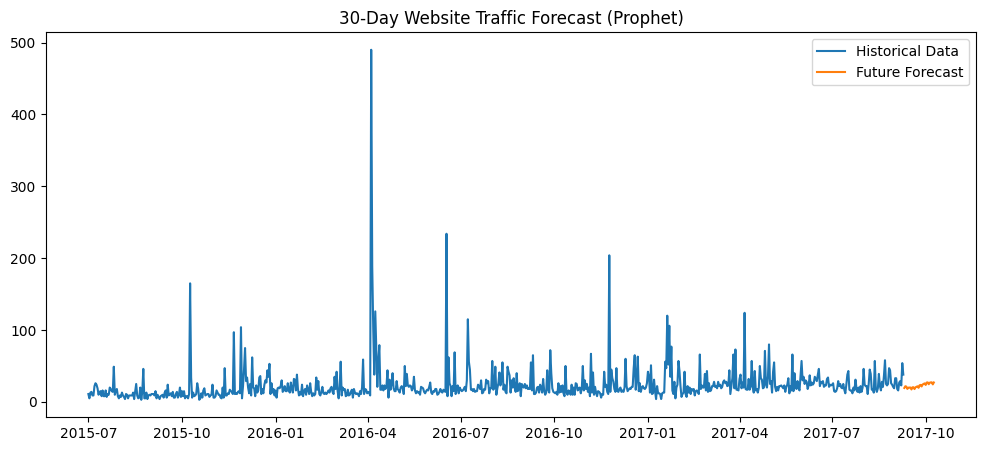

In [61]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["Visitors"], label="Historical Data")
plt.plot(future_forecast.index, future_forecast["Predicted_Visitors"], label="Future Forecast")

plt.legend()
plt.title("30-Day Website Traffic Forecast (Prophet)")
plt.show()

In [71]:
future_forecast.to_csv("../data/prophet_30_days_forecast.csv")

In [66]:
comparison_df = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "Prophet"],
    "RMSE": [rmse_arima, rmse_sarima, rmse_prophet],
    "MAE": [mae_arima, mae_sarima, mae_prophet]
})

comparison_df

,Model,RMSE,MAE
0,ARIMA,15.078377,8.980165
1,SARIMA,15.223764,9.177972
2,Prophet,14.629834,9.285156


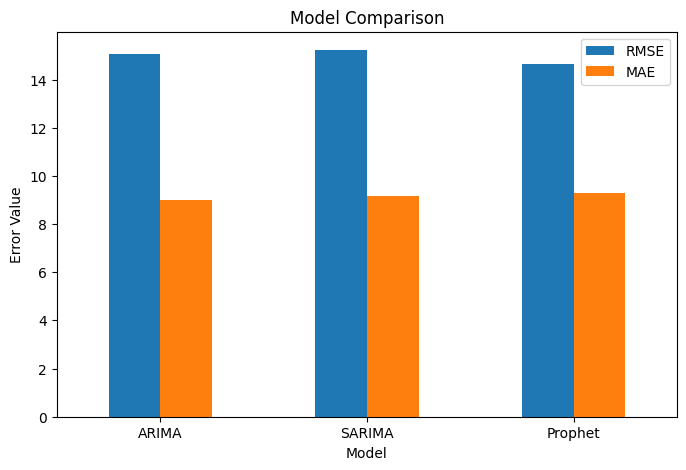

In [67]:
comparison_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.show()

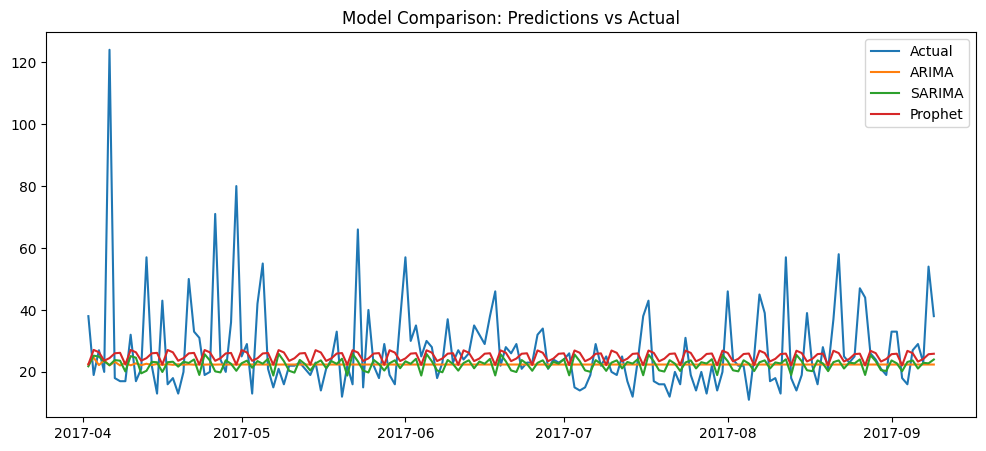

In [68]:
plt.figure(figsize=(12,5))

# Actual data
plt.plot(test.index, test, label="Actual")

# ARIMA
plt.plot(test.index, arima_forecast, label="ARIMA")

# SARIMA
plt.plot(test.index, sarima_forecast, label="SARIMA")

# Prophet
plt.plot(test_prophet["ds"], forecast_test, label="Prophet")

plt.legend()
plt.title("Model Comparison: Predictions vs Actual")
plt.show()